<a href="https://colab.research.google.com/github/Hui0223/pytorch-deep-learning/blob/main/01_pytorch_workflow_video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch Workflow

end to end wordkflow


In [3]:
what_were_covering = {1:"data (prepare and load)",
            2:"build model",
            3:"fitting the model to data (training)",
            4:"making predictions and evaluating a model",
            5:"saving and loading a model",
            6:"putting it all together"}
what_were_covering

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'fitting the model to data (training)',
 4: 'making predictions and evaluating a model',
 5: 'saving and loading a model',
 6: 'putting it all together'}

In [4]:
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

#Check PyTprch version
torch.__version__

'2.11.0+cu128'

Data can be almost anything.. in machine learning.

1.Excel speadsheet

2.Images of any kind

3.Videos (YouTube has lots of data..)

4.DNA

5.Text

Machine learning is a game of two parts:

1.Ger data into a numerical
representation.

2.Build a model to learning patterns in that numerical representation.

To showcase this, let's create some known data using the linear regression formula.

We'll use a linear regression formula to make a straight line with known parameters.


In [5]:
# Create *known* prpameters
weight = 0.7
bias = 0.3

# Create
start = 0
end = 1
step = 0.02
X = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight * X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [6]:
len(X), len(y)

(50, 50)

Splitting data into training and test sets (Important!!!)

Let's create a training and test set with our data.

In [7]:
# Create a train/test split
train_split = int(0.8 * len(X))
train_split

40

In [8]:
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

如何可视化数据？
绘制预测

In [9]:
def plot_predications(train_data = X_train,
            train_labels = y_train,
            test_data = X_test,
            test_labels = y_test,
            predictions = None):
    """
    Plot training data and test data and compares predicitions.

    """
    plt.figure(figsize=(10,7))

    # Plot training data in blue
    plt.scatter(train_data,train_labels,c="b",s=4,label="Training data")

    # Plot test data in green
    plt.scatter(test_data,test_labels,c="g",s=4,label="Testing data")

    # Are there predictions?
    if predictions is not None:
      plt.scatter(test_data,predictions,c="r",s=4,label="Predictions")

    # Show the legend
    plt.legend(prop={"size":14});

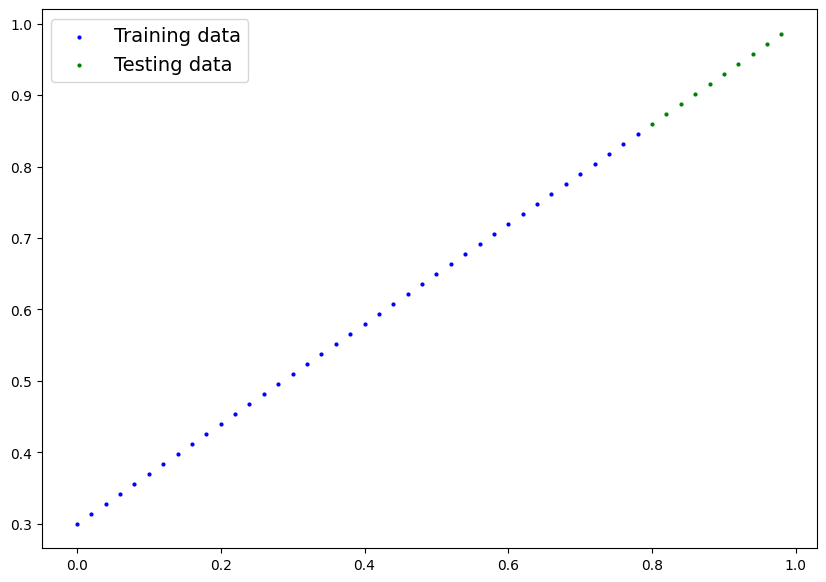

In [10]:
plot_predications()

2. Build model

What our model does？

2.1 Start with random values (weight & bias)

2.2 Look at training data and adjust the random values to better represent (or get closer to) the ideal values (the weight & bias values we used to create the data)

How does it do so?

Through two main algorithms:

1. Gradient descent -> 看 3Blue1Brown的梯度下降视频

2. Backpropagation

In [11]:
from torch import nn
# Create linear regression model class
class LinearRegressionModel(nn.Module): # almost everything in PyTorch inherhits from nn.Module
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1, # start with a random weight and try to adjust it to the ideal weight
                   requires_grad=True, # can this parameter be updated via gradient descent?
                   dtype=torch.float)) # PyTorch loves the datatype torch.float32
    self.bias = nn.Parameter(torch.randn(1,
                        requires_grad=True,
                        dtype=torch.float))
  # Forward method to define the computation in the model
  def forward(self, x:torch.Tensor) -> torch.Tensor: # x is the input data
    return self.weights * x + self.bias


PyTorch model building essentials

1. torch.nn - contains all of the buildings for computational graphs/neural network.

2. torch.nn.Parameter - what parameters should our model try and learn, often a PyTorch layer from torch.nn will set these for us.

3. torch.nn.Module - The base class for all neural network modules, if you subclass it, you should overwrite forward().

4. torch.optim - this where the optimizers in PyTorch live, they will help with gradient descent.

5. def forward() - All nn.Module subclasses require you to overwrite forward(), this method defines what happens in the forward computation.

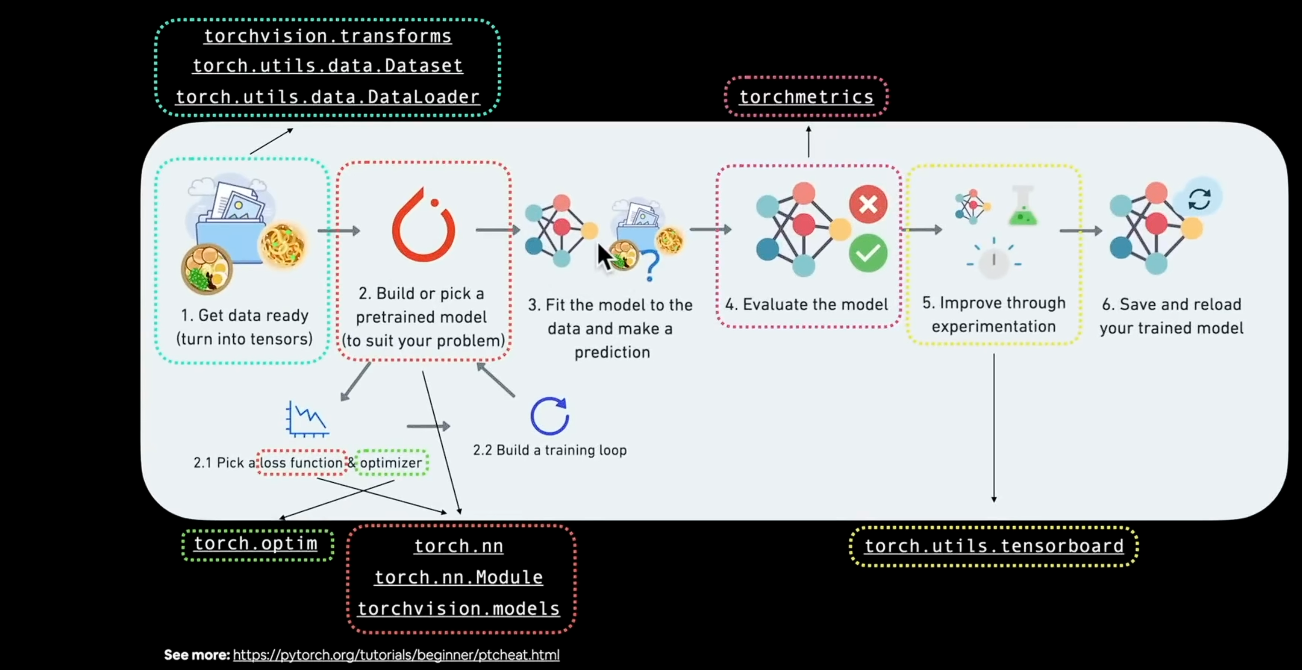



Checking the contents of our PyTorch model

Now we've created a model, let's see what's inside..

So we can check our model parameters or what;s inside our model using .parameters().

In [12]:
# 对比有seed和无seed产生的随机值，有seed，随机值固定，无seed，随机值随机chansheng
torch.randn(1)

tensor([-0.6749])

In [13]:
torch.manual_seed(42)
torch.randn(1)

tensor([0.3367])

In [14]:
# Create a random seed

import torch
torch.manual_seed(42)

# Create an instance of the model (this is s subclass of nn.Module)
model_0 = LinearRegressionModel()

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [15]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [16]:
weight, bias

(0.7, 0.3)

Making prediction using torch.infrence_mode()

To check our model's predictive power, let's see how well it predicts y_test based on X_test.

When we pass data through our model, it's going to run it through the forward() method.

In [17]:
y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)

In [18]:
# Make prediction with model
with torch.inference_mode():
  y_preds = model_0(X_test)

# You can also do something similar with torch.no_grad(), however, torch.inference_mode() is preferred
#with torch.no_grad():
#  y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [19]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

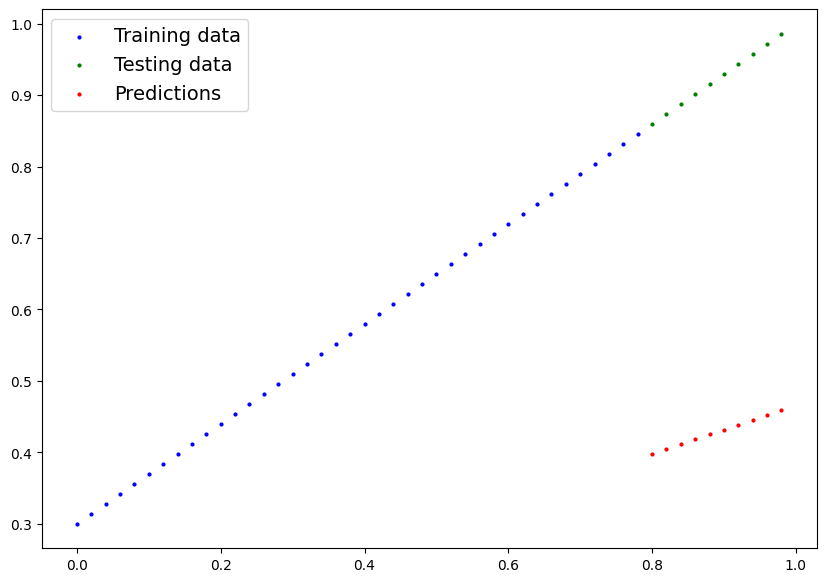

In [20]:
plot_predications(predictions=y_preds)

**3. Train model**

The whole idea of training is for a model to move from some unknown parameters (these may be random) to some known parameters.

Or in other words from a poor representation of the data to a better representation of the data.

On way to measure how poor or how wrong your models predictions are is to use a loss function.

* Note: Loss function may also be called function or criterion in different areas. For our case, we're going to refer to it as a loss function.

Things we need to train:



*   Loss function: A function to measure how wrong your model's predictions are to the ideal outputs, lower is better.
*   Optimizer: Takes into account the loss of a model and adjustd the model's parameters (e.g. weight & bias in our case) to imporve the loss function.

* Inside the optimizer you'll often have to set two parameters:


*   params - the model parameters you'd like to optimize, for example params=model_0.parameters()
*   lr (learning rate) - the learning rate is a hyperparameter that defines how big/small the optimizer changes the parameters with each step (a small lr results in small changes, a large lr results in large changes)


And specifically for PyTorch, we need:



*   A training loop
*   A testing loop





In [21]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [22]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

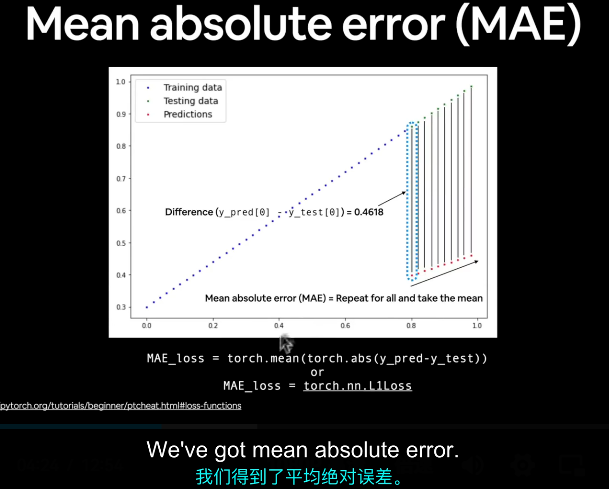

In [23]:
# Setup a loss function
loss_fn = nn.L1Loss()

# Setup an optimizer (stochastic gradient descent - SGD 随机梯度下降法)
optimizer = torch.optim.SGD(params=model_0.parameters(),
              lr = 0.01) # lr = learning rate = possibly the most important hyperparameter you can set. lr越大，参数变动越大，lr越小，参数变动越小

**Q: Which loss function and optimizer should I use?**

A: This will be problem specific. But with experience, you'll get an idea of what works and what doesn't with your particular problem set.

For example, for a regression problem (like ours), a loss function of nn.L1Loss() and an optimizer like torch.optim.SGD() will suffice.

But for a classification problem like classifying whether a photo is of a dog or a cat, you'll likely want to use a loss function of nn.BCELoss() (binary cross entropy loss).

**Building a training loop (and a testing loop) in PyTorch**

A coupld of things we need in a training loop:

0. Loop through the data and do

1. Forward pass (this involves data moving through our model's forward() functions) to make predictions on data - also called forward propagation.

2. Calculate the loss (compare fprward pass predictions to ground truth labels)

3. Optimizer zero grad

4. Loss backward - move backwards through the network to calculate the gradients of each of the parameters of our model with respect to the loss (**backpropagation**)

5. Optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss (**gradient descent**)

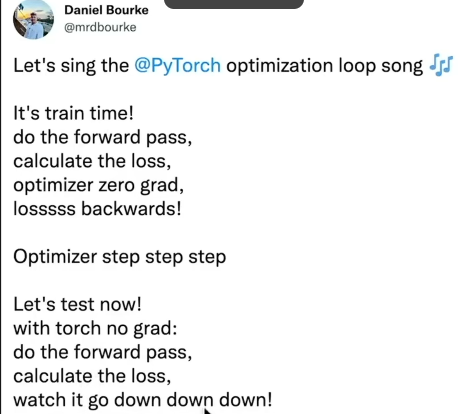

In [24]:
torch.manual_seed(42)

# An epoch is one loop through the data... (this is a hyperparameter because we've set it ourselves)
epochs = 200

# Track different values
epoch_count = []
loss_values = []
test_loss_values = []

# Training
# 0. Loop through the data
for epoch in range(epochs):
  # Set the model to training mode
  model_0.train() # train mode in PyTorch sets all parameters that require gradients to require gradients to requre gradients

  # 1. Forward pass
  y_pred = model_0(X_train)

  # 2. Calculate the loss
  loss = loss_fn(y_pred,y_train)
  print(f"Loss: {loss}")

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Perform backpropagation on the loss with respect to the parameters of the model
  loss.backward()  # 反向传播

  # 5. Step the optimizer (perform gradient descent)
  optimizer.step() # by default how the optimizer changes will acculumate through the loop so... we have to zero them above in step3 for the next interation of the loop.

  # Testing
  model_0.eval() # Turns off different settings in the model not needed for evaluation/testing (dropout/batch norm layers)

  with torch.inference_mode(): # turns off gradient tracking & a couple more things behind the scenes
  # with torch.no_grad(): # you may also see torch.no_grad() in older PyTorch code
    # 1. Do the forward pass
    test_pred = model_0(X_test)

    # 2. Calculate the loss
    test_loss = loss_fn(test_pred,y_test)

  # Print out what's happening
  if epoch % 20 == 0:
    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)
    print(f"Epoch:{epoch} | Loss:{loss} | Test loss: {test_loss}")

  # Print out model state_dict()
  print(model_0.state_dict())

Loss: 0.31288138031959534
Epoch:0 | Loss:0.31288138031959534 | Test loss: 0.48106518387794495
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})
Loss: 0.3013603389263153
OrderedDict({'weights': tensor([0.3445]), 'bias': tensor([0.1488])})
Loss: 0.28983935713768005
OrderedDict({'weights': tensor([0.3484]), 'bias': tensor([0.1588])})
Loss: 0.2783183455467224
OrderedDict({'weights': tensor([0.3523]), 'bias': tensor([0.1688])})
Loss: 0.26679736375808716
OrderedDict({'weights': tensor([0.3562]), 'bias': tensor([0.1788])})
Loss: 0.2552763521671295
OrderedDict({'weights': tensor([0.3601]), 'bias': tensor([0.1888])})
Loss: 0.24375534057617188
OrderedDict({'weights': tensor([0.3640]), 'bias': tensor([0.1988])})
Loss: 0.23223432898521423
OrderedDict({'weights': tensor([0.3679]), 'bias': tensor([0.2088])})
Loss: 0.22071333229541779
OrderedDict({'weights': tensor([0.3718]), 'bias': tensor([0.2188])})
Loss: 0.20919232070446014
OrderedDict({'weights': tensor([0.3757]), 'bias': tens

In [25]:
epoch_count,loss_values,test_loss_values

([0, 20, 40, 60, 80, 100, 120, 140, 160, 180],
 [tensor(0.3129, grad_fn=<MeanBackward0>),
  tensor(0.0891, grad_fn=<MeanBackward0>),
  tensor(0.0454, grad_fn=<MeanBackward0>),
  tensor(0.0382, grad_fn=<MeanBackward0>),
  tensor(0.0313, grad_fn=<MeanBackward0>),
  tensor(0.0245, grad_fn=<MeanBackward0>),
  tensor(0.0176, grad_fn=<MeanBackward0>),
  tensor(0.0107, grad_fn=<MeanBackward0>),
  tensor(0.0039, grad_fn=<MeanBackward0>),
  tensor(0.0089, grad_fn=<MeanBackward0>)],
 [tensor(0.4811),
  tensor(0.2173),
  tensor(0.1136),
  tensor(0.0889),
  tensor(0.0723),
  tensor(0.0565),
  tensor(0.0406),
  tensor(0.0241),
  tensor(0.0082),
  tensor(0.0050)])

/tmp/ipykernel_973/2400875942.py:3: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()),label="Train loss")


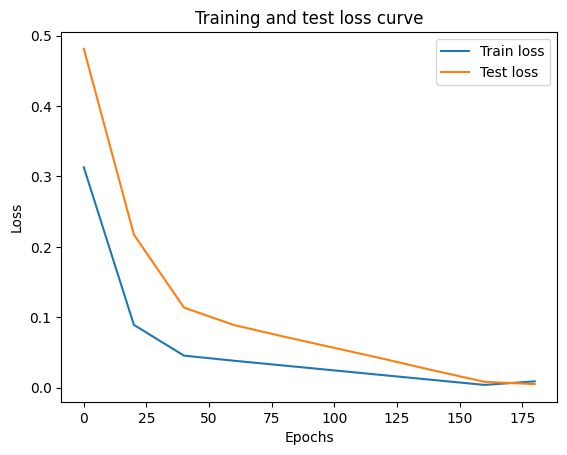

In [26]:
# Plot the loss curves
import numpy as np
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()),label="Train loss")
plt.plot(epoch_count,test_loss_values,label="Test loss")
plt.title("Training and test loss curve")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [27]:
with torch.inference_mode():
  y_preds_new = model_0(X_test)

In [28]:
weight,bias

(0.7, 0.3)

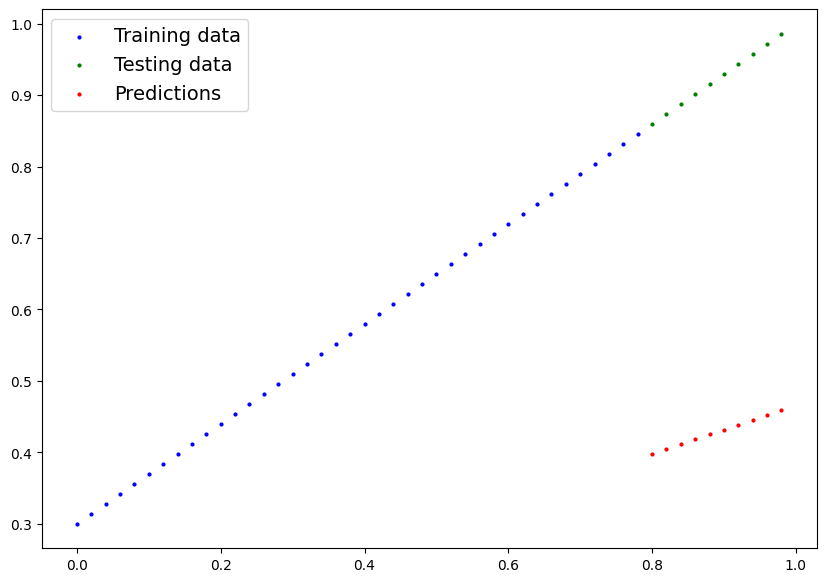

In [29]:
plot_predications(predictions=y_preds);

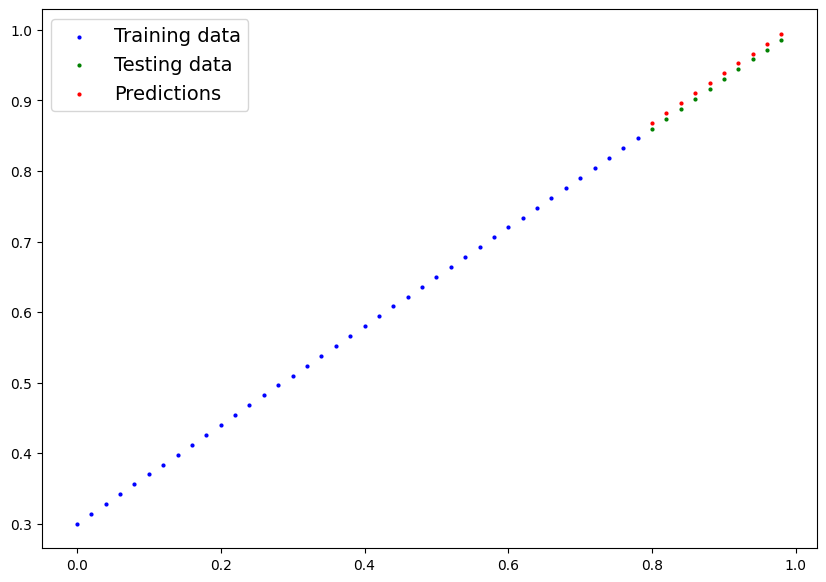

In [30]:
plot_predications(predictions=y_preds_new);

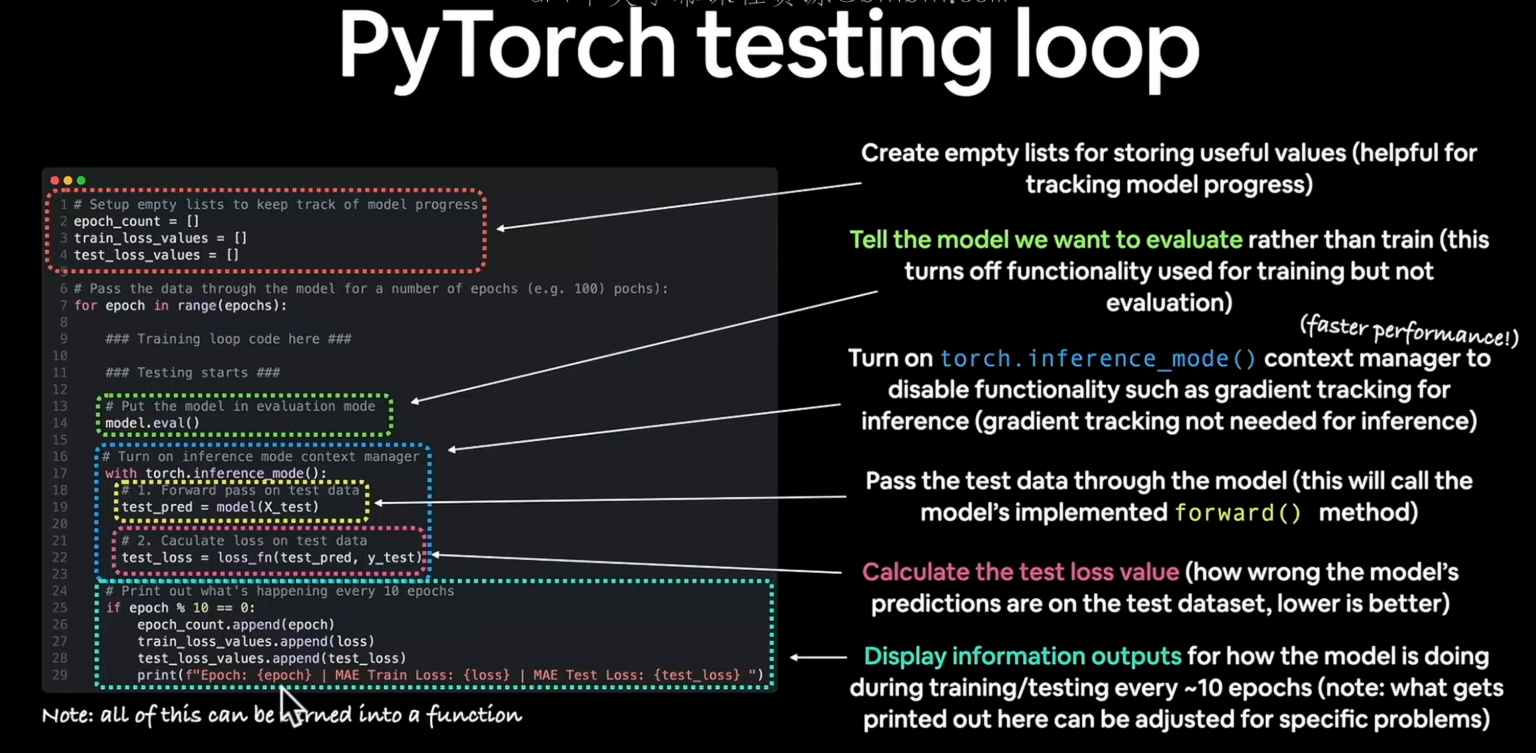

**Saving a model in PyTorch**

There are three main methods you should about for saving and loading models in PyTorch.

1. torch.save() - allows you save a PyTorch object in Python's pickle format.

2. torch.load() - allows you load a saved PyTorch object.

3. torch.nn.Module.load_state_dict() - this allows to load a model's saved state dictionary.

In [32]:
# Saving our PyTorch model
from pathlib import Path

# 1. create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True,exist_ok=True)

# 2. create model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to:{MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(),
        f=MODEL_SAVE_PATH)

Saving model to:models/01_pytorch_workflow_model_0.pth


In [33]:
!ls -l models

total 4
-rw-r--r-- 1 root root 2117 Aug  5 02:29 01_pytorch_workflow_model_0.pth
